## 🔹 Cell 1: Load Dataset

### 📌 What we are doing:
- Loading classification dataset
- Understanding features and target

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd 
data=load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
df.shape
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

# Cell 2 : EDA

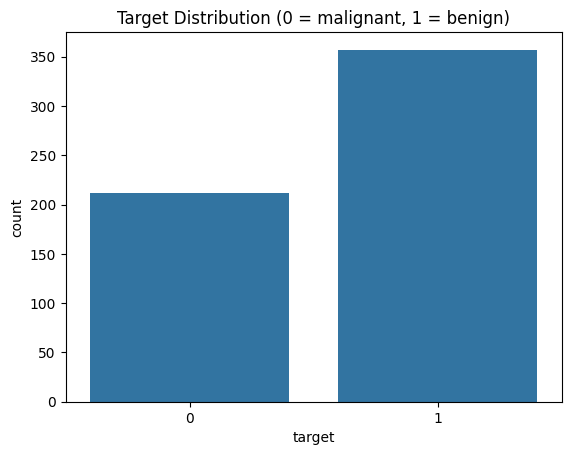

In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.countplot(x='target',data=df)
plt.title("Target Distribution (0 = malignant, 1 = benign)")
plt.show()

# Cell 3: Train Test Split + Scaling

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x=df.drop("target",axis=1)
y=df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
print("Train shape:", x_train_scaled.shape)
print("Test shape:", x_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## 🔹 Cell 4: Logistic Regression

### 📌 What we are doing:
- Training first classification model
- Predicting cancer type (malignant / benign)
- Evaluating performance

In [5]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred_log=log_model.predict(x_test_scaled)
# Check first few predictions
print("Predictions:", y_pred_log[:10])

Predictions: [1 0 0 1 1 0 0 0 1 1]


In [6]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred_log)
print("Accuracy is ",accuracy)

Accuracy is  0.9736842105263158


## 🔹 Cell 5: Confusion Matrix & Classification Metrics

### 📌 What we are doing:
- Evaluating model beyond accuracy
- Understanding prediction types
- Calculating Precision, Recall, F1-score

In [7]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred_log)
print("confusion matrix=\n",cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

confusion matrix=
 [[41  2]
 [ 1 70]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 🔹 Cell 6: ROC Curve & AUC

### 📌 What we are doing:
- Evaluating model using probability
- Understanding model performance across thresholds
- Plotting ROC Curve

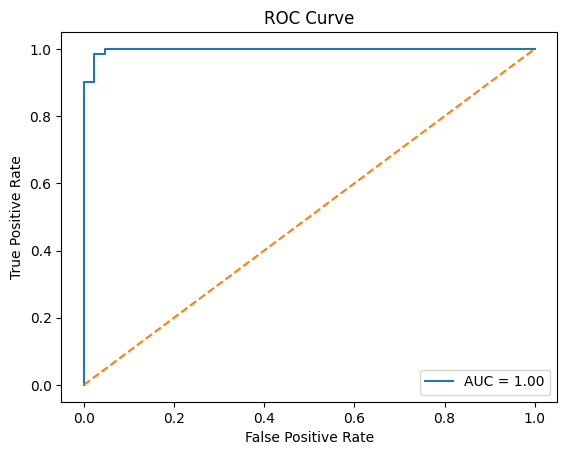

AUC Score: 0.99737962659679


In [8]:
from sklearn.metrics import roc_curve,roc_auc_score
# Get probabilities
y_prob=log_model.predict_proba(x_test_scaled)[:,1]
# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# AUC score
auc_score = roc_auc_score(y_test, y_prob)
# Plot
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("AUC Score:", auc_score)

## 🔹 Cell 7: Decision Tree (Classification)

### 📌 What we are doing:
- Training Decision Tree classifier
- Comparing with Logistic Regression

In [9]:
from sklearn.tree import DecisionTreeClassifier
tree_clf=DecisionTreeClassifier(random_state=42)
tree_clf.fit(x_train,y_train)
y_pred_tree=tree_clf.predict(x_test)
from sklearn.metrics import accuracy_score
acc_tree=accuracy_score(y_test,y_pred_tree)
print("decision tree accuracy:",acc_tree)

y_train_pred_tree = tree_clf.predict(x_train)
from sklearn.metrics import accuracy_score
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_tree))
print("Test Accuracy:", accuracy_score(y_test, y_pred_tree))
#it is overfitting 

decision tree accuracy: 0.9473684210526315
Train Accuracy: 1.0
Test Accuracy: 0.9473684210526315


## 🔹 Cell 8: Random Forest (Classification)

### 📌 What we are doing:
- Using multiple trees
- Reducing overfitting
- Improving performance

In [10]:
from sklearn.ensemble import RandomForestClassifier
rf_clf=RandomForestClassifier(n_estimators=100,random_state=42)
rf_clf.fit(x_train,y_train)
y_pred_rf=rf_clf.predict(x_test)
acc_rf=accuracy_score(y_test,y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.9649122807017544


## 🔹 Cell 9: Gradient Boosting (Classification)

### 📌 What we are doing:
- Applying Gradient Boosting Classifier
- Learning from mistakes step-by-step

In [11]:
from sklearn.ensemble import GradientBoostingClassifier 
gb_clf=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,random_state=42)
gb_clf.fit(x_train,y_train)
y_pred_gb=gb_clf.predict(x_test)
acc_gb=accuracy_score(y_test,y_pred_gb)
print("Gradient Boosting Accuracy:", acc_gb)

Gradient Boosting Accuracy: 0.956140350877193


## 🔹 Cell 10: ROC Curve Comparison

### 📌 What we are doing:
- Comparing all models using ROC Curve
- Evaluating which model separates classes best

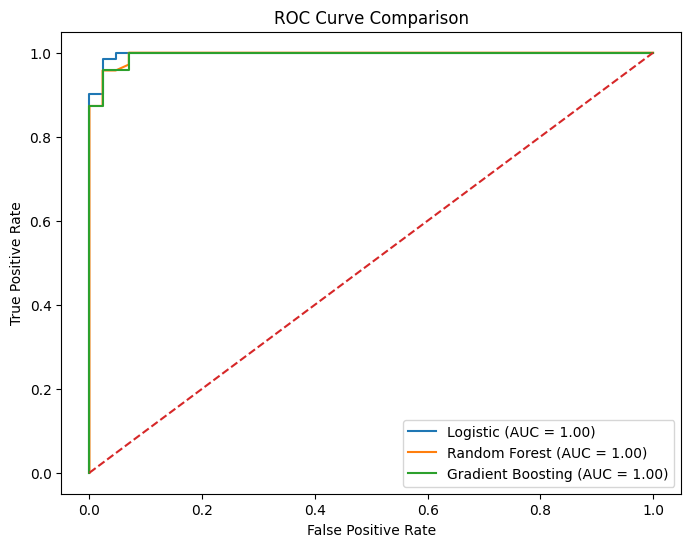

In [13]:
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt
y_prob_log = log_model.predict_proba(x_test_scaled)[:, 1]
y_prob_rf = rf_clf.predict_proba(x_test)[:, 1]
y_prob_gb = gb_clf.predict_proba(x_test)[:, 1]

# ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

# AUC scores
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gb = roc_auc_score(y_test, y_prob_gb)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.2f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 🔹 Cell 11: Feature Importance

### 📌 What we are doing:
- Understanding which features matter most
- Using Random Forest for importance

In [14]:
import pandas as pd
importance=rf_clf.feature_importances_
feature_importance=pd.DataFrame({
    'Feature':x.columns,
    'Importance':importance
}).sort_values(by='Importance', ascending=False)
feature_importance.head(10)

,Feature,Importance
23,worst area,0.153892
27,worst concave points,0.144663
7,mean concave points,0.106210
20,worst radius,0.077987
6,mean concavity,0.068001
22,worst perimeter,0.067115
2,mean perimeter,0.053270
0,mean radius,0.048703
3,mean area,0.047555
26,worst concavity,0.031802


## 🔹 Cell 12: Cross Validation

### 📌 What we are doing:
- Evaluating model stability
- Using multiple splits instead of one

In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(log_model, x_train_scaled, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.97802198 0.96703297 1.         0.97802198 0.94505495]
Average accuracy: 0.9736263736263737


## 🔹 Cell 13: Hyperparameter Tuning

### 📌 What we are doing:
- Finding best parameters for Logistic Regression

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(x_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.1, 'solver': 'liblinear'}


## 🔹 Cell 14: XGBoost (Classification)

### 📌 What we are doing:
- Applying advanced boosting model

In [18]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

xgb_clf.fit(x_train, y_train)

y_pred_xgb = xgb_clf.predict(x_test)

from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.956140350877193
